In [1]:
# =============================================================================
# 0. Imports y configuración
# =============================================================================
import json
import math
import time
from pathlib import Path
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.utils.tensorboard import SummaryWriter
 
from datasets import load_dataset
from tokenizers import Tokenizer
 
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
 
SEED = 42
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


In [2]:
# =============================================================================
# 1. Cargar artefactos de NB1
# =============================================================================
# Asegúrate de tener en el directorio de trabajo:
#   tweet_wordlevel_tokenizer.json
#   nb1_config.json
# (generados por el NB1 del taller de LSTMs)

tokenizer = Tokenizer.from_file("tweet_wordlevel_tokenizer.json")
 
with open("nb1_config.json") as f:
    config = json.load(f)
 
VOCAB_SIZE  = config["vocab_size"]
PAD_IDX     = config["pad_idx"]
MAX_LEN     = config["max_len"]
BATCH_SIZE  = config["batch_size"]
NUM_CLASSES = config["num_classes"]
LABEL_NAMES = {int(k): v for k, v in config["label_names"].items()}
 
print(f"Vocab size : {VOCAB_SIZE:,}")
print(f"PAD_IDX    : {PAD_IDX}")
print(f"MAX_LEN    : {MAX_LEN}")
print(f"Clases     : {LABEL_NAMES}")

Vocab size : 19,422
PAD_IDX    : 0
MAX_LEN    : 128
Clases     : {0: 'negative', 1: 'neutral', 2: 'positive'}


In [3]:
# =============================================================================
# 2. Dataset y DataLoader  (idéntico al NB2 — baseline)
# =============================================================================
import re
 
def clean_tweet(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "<URL>", text)
    text = re.sub(r"@\w+", "<USER>", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-z0-9<>\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
 
 
class TweetDataset(Dataset):
    def __init__(self, hf_split, tokenizer, max_len=MAX_LEN):
        self.data      = hf_split
        self.tokenizer = tokenizer
        self.max_len   = max_len
 
    def __len__(self):
        return len(self.data)
 
    def __getitem__(self, idx):
        example = self.data[idx]
        ids = self.tokenizer.encode(clean_tweet(example["text"])).ids[: self.max_len]
        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(example["label"], dtype=torch.long),
        )
 
 
def collate_fn(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in sequences], dtype=torch.long)
    padded  = pad_sequence(sequences, batch_first=True, padding_value=PAD_IDX)
    return padded, torch.stack(labels), lengths
 
 
dataset      = load_dataset("tweet_eval", "sentiment")
train_loader = DataLoader(TweetDataset(dataset["train"],      tokenizer),
                          batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(TweetDataset(dataset["validation"], tokenizer),
                          batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(TweetDataset(dataset["test"],       tokenizer),
                          batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
 
print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")


Batches — train: 713 | val: 32 | test: 192


In [4]:
# =============================================================================
# 3. Utilidades de entrenamiento  (igual que NB2)
# =============================================================================
 
def run_epoch(model, loader, criterion, optimizer=None):
    """Train si optimizer is not None, eval en otro caso."""
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, n = 0.0, 0, 0
 
    with torch.set_grad_enabled(training):
        for ids, labels, lengths in loader:
            ids, labels, lengths = ids.to(DEVICE), labels.to(DEVICE), lengths.to(DEVICE)
            preds = model(ids, lengths)
            loss  = criterion(preds, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * ids.size(0)
            correct    += (preds.argmax(dim=1) == labels).sum().item()
            n          += ids.size(0)
 
    return total_loss / n, correct / n
 
 
@torch.no_grad()
def evaluate_clf(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_preds, all_labels  = [], []
 
    for ids, labels, lengths in loader:
        ids, labels, lengths = ids.to(DEVICE), labels.to(DEVICE), lengths.to(DEVICE)
        logits = model(ids, lengths)
        loss   = criterion(logits, labels)
        preds  = logits.argmax(dim=1)
        total_loss += loss.item() * ids.size(0)
        correct    += (preds == labels).sum().item()
        n          += ids.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
 
    return total_loss / n, correct / n, all_preds, all_labels
 
 
class ModelCheckpoint:
    """Guarda el mejor modelo según una métrica monitoreada."""
    def __init__(self, filepath, monitor="val_acc", mode="max", verbose=True):
        self.filepath = filepath
        self.monitor  = monitor
        self.verbose  = verbose
        self.best     = float("-inf") if mode == "max" else float("inf")
        self.mode     = mode
 
    def step(self, metrics, model):
        value    = metrics[self.monitor]
        improved = value > self.best if self.mode == "max" else value < self.best
        if improved:
            self.best = value
            torch.save(model.state_dict(), self.filepath)
            if self.verbose:
                print(f"  ✓ Mejor modelo guardado ({self.monitor}: {value:.4f})")
        return improved


In [5]:
# =============================================================================
# 4. Visualización
# =============================================================================
 
def plot_history(histories: dict):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for name, h in histories.items():
        axes[0].plot(h["train_loss"], label=f"{name} train")
        axes[0].plot(h["val_loss"],   label=f"{name} val", linestyle="--")
        axes[1].plot(h["train_acc"],  label=f"{name} train")
        axes[1].plot(h["val_acc"],    label=f"{name} val", linestyle="--")
    axes[0].set_title("Loss");     axes[0].legend(); axes[0].set_xlabel("Época")
    axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("Época")
    plt.tight_layout()
    plt.show()
 
 
def full_report(model, loader, model_name: str):
    target_names = [LABEL_NAMES[i] for i in range(NUM_CLASSES)]
    _, acc, preds, labels = evaluate_clf(model, loader, criterion)
 
    print(f"\n{'='*55}")
    print(f"  {model_name} — Test Accuracy: {acc:.4f}")
    print(f"{'='*55}")
    print(classification_report(labels, preds, target_names=target_names, digits=4))
 
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
 
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ["d", ".2f"],
        ["Conteos absolutos", "Proporción por clase (recall)"],
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=target_names, yticklabels=target_names, ax=ax)
        ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
        ax.set_title(f"{model_name}\n{title}")
    plt.tight_layout()
    plt.show()


In [6]:
# =============================================================================
# 5. Hiperparámetros globales del transformer
# =============================================================================
 
EMBED_DIM   = 128   # d_model
NUM_HEADS   = 4     # debe dividir EMBED_DIM
FF_DIM      = 256   # dimensión interna del feed-forward
DROPOUT     = 0.1
NUM_LAYERS  = 2     # capas TransformerEncoder apiladas
EPOCHS      = 10
LR          = 1e-3
 
criterion = nn.CrossEntropyLoss()


In [7]:
class TransformerEncoderBlock(nn.Module):
    """
    Un bloque Transformer estándar (Pre-LN opcional):
 
        x → LN → MHSA → residual
          → LN → FFN  → residual
 
    Parámetros
    ----------
    embed_dim  : d_model
    num_heads  : cabezas de atención
    ff_dim     : dimensión oculta del feed-forward
    dropout    : tasa de dropout aplicada después de atención y FFN
    """
    def __init__(self, embed_dim: int, num_heads: int,
                 ff_dim: int, dropout: float = 0.1):
        super().__init__()
        self.attn   = nn.MultiheadAttention(embed_dim, num_heads,
                                            dropout=dropout, batch_first=True)
        self.ff     = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
        )
        self.norm1  = nn.LayerNorm(embed_dim)
        self.norm2  = nn.LayerNorm(embed_dim)
        self.drop   = nn.Dropout(dropout)
 
    def forward(self, x: torch.Tensor,
                key_padding_mask: torch.Tensor | None = None) -> torch.Tensor:
        """
        x                : (B, L, E)
        key_padding_mask : (B, L)  — True donde hay PAD
        """
        # --- Self-Attention con residual (Pre-LN) ---
        normed  = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed,
                                key_padding_mask=key_padding_mask)
        x = x + self.drop(attn_out)
 
        # --- Feed-Forward con residual ---
        x = x + self.drop(self.ff(self.norm2(x)))
        return x
 


In [8]:
# Head de clasificación compartida: pooling sobre tokens no-PAD → Linear
class MeanPoolClassifier(nn.Module):
    """
    Promedia los hidden states de tokens reales (ignora PAD)
    y aplica una capa lineal de clasificación.
    """
    def __init__(self, embed_dim: int, num_classes: int, dropout: float = 0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(embed_dim, num_classes)
 
    def forward(self, hidden: torch.Tensor,
                ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        """
        hidden  : (B, L, E)
        ids     : (B, L) — para construir la máscara de PAD
        lengths : (B,)   — número de tokens reales por ejemplo
        """
        mask    = (ids != PAD_IDX).unsqueeze(-1).float()   # (B, L, 1)
        summed  = (hidden * mask).sum(dim=1)               # (B, E)
        averaged = summed / lengths.unsqueeze(-1).float().clamp(min=1)
        return self.head(self.drop(averaged))              # (B, C)
 


In [9]:
# =============================================================================
# 7. Modelo 1: TransformerClassifier  (sin positional encoding)
# =============================================================================
# Arquitectura:
#
#   ids (B, L)
#     └─ Embedding → (B, L, E)
#          └─ N × TransformerEncoderBlock   ← atención ignora el orden
#               └─ MeanPool + Linear → logits (B, C)
#
# Sin ningún PE el modelo es un "set transformer":
# no tiene información del orden de los tokens.
 
class TransformerClassifier(nn.Module):
    """
    Transformer encoder para clasificación de secuencias.
    NO usa positional encoding: la atención es invariante al orden.
 
    Parámetros
    ----------
    vocab_size  : tamaño del vocabulario
    embed_dim   : d_model
    num_heads   : cabezas de atención (debe dividir embed_dim)
    ff_dim      : dim. oculta del feed-forward
    num_layers  : capas apiladas
    num_classes : clases de salida
    pad_idx     : índice de <PAD>
    dropout     : tasa de dropout
    """
    def __init__(self, vocab_size: int, embed_dim: int, num_heads: int,
                 ff_dim: int, num_layers: int, num_classes: int,
                 pad_idx: int, dropout: float = 0.1):
        super().__init__()
        self.pad_idx   = pad_idx
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.drop      = nn.Dropout(dropout)
        self.layers    = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.pool = MeanPoolClassifier(embed_dim, num_classes, dropout)
 
    def forward(self, ids: torch.Tensor,
                lengths: torch.Tensor) -> torch.Tensor:
        # Máscara de PAD para nn.MultiheadAttention (True = ignorar)
        pad_mask = (ids == self.pad_idx)                   # (B, L)
 
        x = self.drop(self.embedding(ids))                 # (B, L, E)
        for layer in self.layers:
            x = layer(x, key_padding_mask=pad_mask)        # (B, L, E)
        return self.pool(x, ids, lengths)                  # (B, C)


In [10]:
# --- Setup Modelo 1 ---
model1     = TransformerClassifier(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
    ff_dim=FF_DIM, num_layers=NUM_LAYERS, num_classes=NUM_CLASSES,
    pad_idx=PAD_IDX, dropout=DROPOUT,
).to(DEVICE)
opt1       = torch.optim.Adam(model1.parameters(), lr=LR)
ckpt1      = ModelCheckpoint("transformer_nope_best.pt", monitor="val_acc")
writer1    = SummaryWriter(log_dir="runs/transformer_nope")
 
print(f"\n[Modelo 1] Parámetros: {sum(p.numel() for p in model1.parameters()):,}")


[Modelo 1] Parámetros: 2,751,363


In [11]:
# --- Training loop Modelo 1 ---
history1 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
 
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model1, train_loader, criterion, opt1)
    val_loss,   val_acc   = run_epoch(model1, val_loader,   criterion)
 
    history1["train_loss"].append(train_loss)
    history1["val_loss"].append(val_loss)
    history1["train_acc"].append(train_acc)
    history1["val_acc"].append(val_acc)
 
    writer1.add_scalars("Loss",     {"train": train_loss, "val": val_loss}, epoch)
    writer1.add_scalars("Accuracy", {"train": train_acc,  "val": val_acc},  epoch)
 
    print(f"Epoch {epoch:02d}/{EPOCHS} — "
          f"train loss: {train_loss:.4f}, acc: {train_acc:.3f} | "
          f"val loss: {val_loss:.4f}, acc: {val_acc:.3f}")
    ckpt1.step({"val_acc": val_acc}, model1)

writer1.close()


Epoch 01/10 — train loss: 0.9007, acc: 0.564 | val loss: 0.8355, acc: 0.609
  ✓ Mejor modelo guardado (val_acc: 0.6090)
Epoch 02/10 — train loss: 0.7792, acc: 0.640 | val loss: 0.7980, acc: 0.641
  ✓ Mejor modelo guardado (val_acc: 0.6410)
Epoch 03/10 — train loss: 0.7101, acc: 0.680 | val loss: 0.7816, acc: 0.664
  ✓ Mejor modelo guardado (val_acc: 0.6640)


KeyboardInterrupt: 

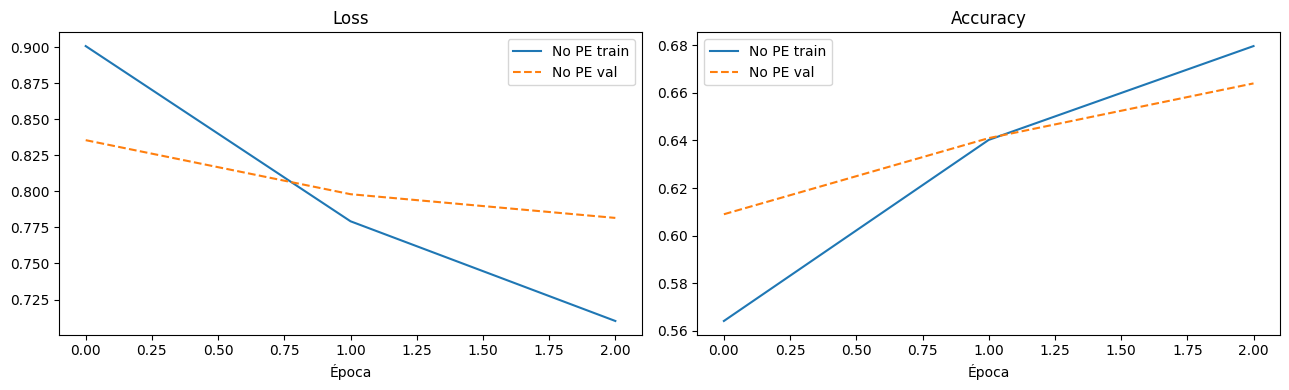

In [12]:
plot_history({
    "No PE":       history1,
})


  Baseline (mean pooling) — Test Accuracy: 0.5703
              precision    recall  f1-score   support

    negative     0.5428    0.5471    0.5450      3972
     neutral     0.6066    0.5848    0.5955      5937
    positive     0.5319    0.5726    0.5515      2375

    accuracy                         0.5703     12284
   macro avg     0.5604    0.5682    0.5640     12284
weighted avg     0.5715    0.5703    0.5706     12284



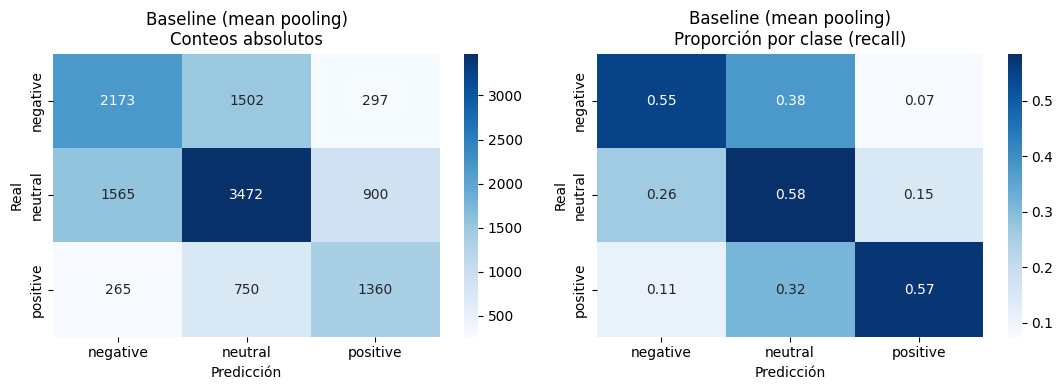

In [13]:
# Carga el mejor checkpoint antes de evaluar en test
model1.load_state_dict(torch.load("transformer_nope_best.pt", map_location=DEVICE))
full_report(model1, test_loader, "Baseline (mean pooling)")

In [15]:
# =============================================================================
# 8. Modelo 2: TransformerWithLearnablePE
# =============================================================================
# Novedad: se suma un embedding de posición *aprendido* a cada token.
#
#   ids (B, L)
#     ├─ TokenEmbedding    → (B, L, E)
#     └─ PositionEmbedding → (B, L, E)   ← nn.Embedding(max_len, E)
#          └─ suma → (B, L, E)
#               └─ N × TransformerEncoderBlock
#                    └─ MeanPool + Linear → logits (B, C)
#
# El modelo aprende *qué* información asociar a cada posición,
# sin imponer ninguna estructura geométrica.
 
class TransformerWithLearnablePE(nn.Module):
    """
    Transformer con Positional Encoding learnable.
 
    Suma un embedding de posición entrenado (nn.Embedding(max_len, embed_dim))
    al embedding de token antes de los bloques de atención.
 
    Parámetros
    ----------
    max_len : longitud máxima de secuencia (necesaria para el PE learnable)
    resto   : igual que TransformerClassifier
    """
    def __init__(self, vocab_size: int, embed_dim: int, num_heads: int,
                 ff_dim: int, num_layers: int, num_classes: int,
                 pad_idx: int, max_len: int, dropout: float = 0.1):
        super().__init__()
        self.pad_idx    = pad_idx
        self.tok_emb    = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        # ── Learnable positional embedding ──────────────────────────────────
        self.pos_emb    = nn.Embedding(max_len, embed_dim)
        # ────────────────────────────────────────────────────────────────────
        self.drop       = nn.Dropout(dropout)
        self.layers     = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.pool = MeanPoolClassifier(embed_dim, num_classes, dropout)
 
    def forward(self, ids: torch.Tensor,
                lengths: torch.Tensor) -> torch.Tensor:
        B, L    = ids.shape
        pad_mask = (ids == self.pad_idx)
 
        # Posiciones 0, 1, …, L-1 para cada ejemplo del batch
        positions = torch.arange(L, device=ids.device).unsqueeze(0)  # (1, L)
 
        x = self.tok_emb(ids) + self.pos_emb(positions)   # (B, L, E)
        x = self.drop(x)
        for layer in self.layers:
            x = layer(x, key_padding_mask=pad_mask)
        return self.pool(x, ids, lengths)


In [16]:
# --- Setup Modelo 2 ---
model2  = TransformerWithLearnablePE(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
    ff_dim=FF_DIM, num_layers=NUM_LAYERS, num_classes=NUM_CLASSES,
    pad_idx=PAD_IDX, max_len=MAX_LEN, dropout=DROPOUT,
).to(DEVICE)
opt2    = torch.optim.Adam(model2.parameters(), lr=LR)
ckpt2   = ModelCheckpoint("transformer_learnable_pe_best.pt", monitor="val_acc")
writer2 = SummaryWriter(log_dir="runs/transformer_learnable_pe")
 
print(f"\n[Modelo 2] Parámetros: {sum(p.numel() for p in model2.parameters()):,}")



[Modelo 2] Parámetros: 2,757,763


In [17]:
# --- Training loop Modelo 2 ---
history2 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
 
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model2, train_loader, criterion, opt2)
    val_loss,   val_acc   = run_epoch(model2, val_loader,   criterion)
 
    history2["train_loss"].append(train_loss)
    history2["val_loss"].append(val_loss)
    history2["train_acc"].append(train_acc)
    history2["val_acc"].append(val_acc)
 
    writer2.add_scalars("Loss",     {"train": train_loss, "val": val_loss}, epoch)
    writer2.add_scalars("Accuracy", {"train": train_acc,  "val": val_acc},  epoch)
 
    print(f"Epoch {epoch:02d}/{EPOCHS} — "
          f"train loss: {train_loss:.4f}, acc: {train_acc:.3f} | "
          f"val loss: {val_loss:.4f}, acc: {val_acc:.3f}")
    ckpt2.step({"val_acc": val_acc}, model2)
 
writer2.close()


Epoch 01/10 — train loss: 0.9253, acc: 0.546 | val loss: 0.8650, acc: 0.600
  ✓ Mejor modelo guardado (val_acc: 0.5995)
Epoch 02/10 — train loss: 0.8061, acc: 0.624 | val loss: 0.8043, acc: 0.633
  ✓ Mejor modelo guardado (val_acc: 0.6335)
Epoch 03/10 — train loss: 0.7297, acc: 0.667 | val loss: 0.7951, acc: 0.644
  ✓ Mejor modelo guardado (val_acc: 0.6440)
Epoch 04/10 — train loss: 0.6714, acc: 0.700 | val loss: 0.7791, acc: 0.656
  ✓ Mejor modelo guardado (val_acc: 0.6565)
Epoch 05/10 — train loss: 0.6221, acc: 0.726 | val loss: 0.7917, acc: 0.656
Epoch 06/10 — train loss: 0.5754, acc: 0.752 | val loss: 0.8098, acc: 0.653
Epoch 07/10 — train loss: 0.5355, acc: 0.771 | val loss: 0.8362, acc: 0.658
  ✓ Mejor modelo guardado (val_acc: 0.6580)
Epoch 08/10 — train loss: 0.4979, acc: 0.791 | val loss: 0.8670, acc: 0.654
Epoch 09/10 — train loss: 0.4590, acc: 0.808 | val loss: 0.8729, acc: 0.656
Epoch 10/10 — train loss: 0.4230, acc: 0.826 | val loss: 0.9686, acc: 0.659
  ✓ Mejor modelo gua

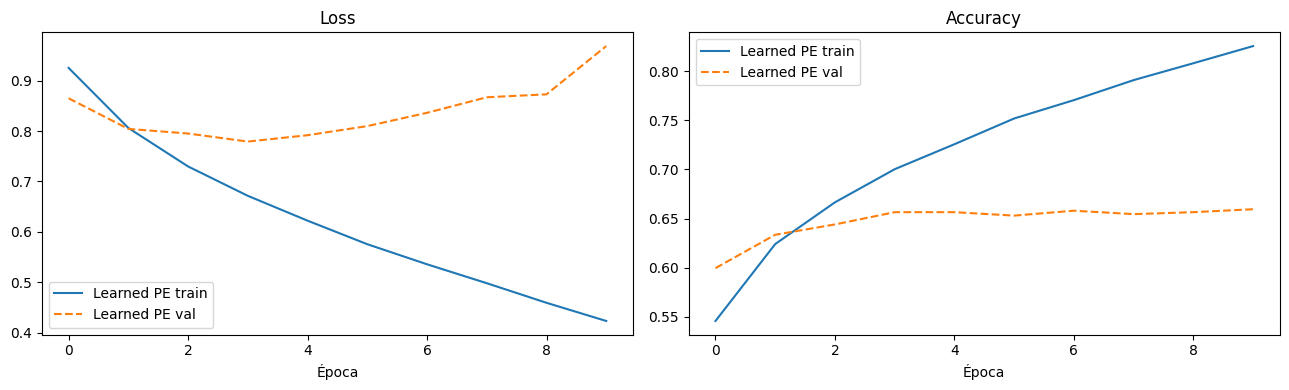


  Model 2 (mean pooling) — Test Accuracy: 0.5726
              precision    recall  f1-score   support

    negative     0.6469    0.3625    0.4647      3972
     neutral     0.5806    0.6993    0.6345      5937
    positive     0.4960    0.6072    0.5460      2375

    accuracy                         0.5726     12284
   macro avg     0.5745    0.5563    0.5484     12284
weighted avg     0.5857    0.5726    0.5625     12284



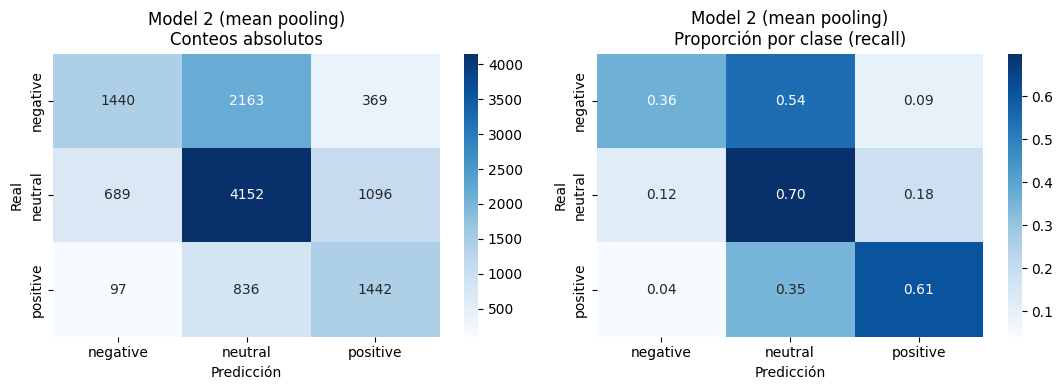

In [24]:
# Carga el mejor checkpoint antes de evaluar en test
plot_history({
    "Learned PE": history2,
})

model2.load_state_dict(torch.load("transformer_learnable_pe_best.pt", map_location=DEVICE))
full_report(model2, test_loader, "Model 2 (mean pooling)")

In [20]:
# =============================================================================
# 9. Modelo 3: TransformerWithSinusoidalPE
# =============================================================================
# Novedad: positional encoding sinusoidal fijo (Vaswani et al., 2017).
#
#   PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
#   PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
#
# No tiene parámetros entrenables para las posiciones.
# Puede generalizarse a longitudes no vistas durante el entrenamiento.
 
class SinusoidalPositionalEncoding(nn.Module):
    """
    Positional Encoding sinusoidal fijo (Vaswani et al., 2017).
 
    Registra el buffer `pe` de forma (1, max_len, embed_dim).
    Al hacer forward suma PE a la secuencia de embeddings.
 
    Parámetros
    ----------
    embed_dim : d_model
    max_len   : longitud máxima de secuencia soportada
    dropout   : dropout aplicado después de la suma
    """
    def __init__(self, embed_dim: int, max_len: int, dropout: float = 0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
 
        # ── Construir la tabla PE ───────────────────────────────────────────
        pe       = torch.zeros(max_len, embed_dim)             # (max_len, E)
        position = torch.arange(max_len).unsqueeze(1).float()  # (max_len, 1)
        # div_term: 10000^(2i/d_model) para i = 0, 1, …, E/2-1
        div_term = torch.exp(
            torch.arange(0, embed_dim, 2).float()
            * (-math.log(10_000.0) / embed_dim)
        )                                                       # (E/2,)
        pe[:, 0::2] = torch.sin(position * div_term)           # posiciones pares
        pe[:, 1::2] = torch.cos(position * div_term)           # posiciones impares
        # ───────────────────────────────────────────────────────────────────
 
        # Buffer: se mueve con .to(device) pero no es parámetro entrenado
        self.register_buffer("pe", pe.unsqueeze(0))            # (1, max_len, E)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x : (B, L, E)"""
        return self.drop(x + self.pe[:, : x.size(1)])
 
 
class TransformerWithSinusoidalPE(nn.Module):
    """
    Transformer con Positional Encoding sinusoidal (no entrenable).
 
    Suma la tabla PE de Vaswani et al. al embedding de token.
    El resto de la arquitectura es idéntico al Modelo 2.
    """
    def __init__(self, vocab_size: int, embed_dim: int, num_heads: int,
                 ff_dim: int, num_layers: int, num_classes: int,
                 pad_idx: int, max_len: int, dropout: float = 0.1):
        super().__init__()
        self.pad_idx    = pad_idx
        self.tok_emb    = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        # ── Sinusoidal positional encoding ──────────────────────────────────
        self.pos_enc    = SinusoidalPositionalEncoding(embed_dim, max_len, dropout)
        # ────────────────────────────────────────────────────────────────────
        self.layers     = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.pool = MeanPoolClassifier(embed_dim, num_classes, dropout)
 
    def forward(self, ids: torch.Tensor,
                lengths: torch.Tensor) -> torch.Tensor:
        pad_mask = (ids == self.pad_idx)
        x = self.pos_enc(self.tok_emb(ids))   # (B, L, E)  ← PE ya incluye dropout
        for layer in self.layers:
            x = layer(x, key_padding_mask=pad_mask)
        return self.pool(x, ids, lengths)

In [21]:
# --- Setup Modelo 3 ---
model3  = TransformerWithSinusoidalPE(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
    ff_dim=FF_DIM, num_layers=NUM_LAYERS, num_classes=NUM_CLASSES,
    pad_idx=PAD_IDX, max_len=MAX_LEN, dropout=DROPOUT,
).to(DEVICE)
opt3    = torch.optim.Adam(model3.parameters(), lr=LR)
ckpt3   = ModelCheckpoint("transformer_sinusoidal_pe_best.pt", monitor="val_acc")
writer3 = SummaryWriter(log_dir="runs/transformer_sinusoidal_pe")
 
print(f"\n[Modelo 3] Parámetros: {sum(p.numel() for p in model3.parameters()):,}")



[Modelo 3] Parámetros: 2,751,363


In [22]:
# --- Training loop Modelo 3 ---
history3 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
 
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model3, train_loader, criterion, opt3)
    val_loss,   val_acc   = run_epoch(model3, val_loader,   criterion)
 
    history3["train_loss"].append(train_loss)
    history3["val_loss"].append(val_loss)
    history3["train_acc"].append(train_acc)
    history3["val_acc"].append(val_acc)
 
    writer3.add_scalars("Loss",     {"train": train_loss, "val": val_loss}, epoch)
    writer3.add_scalars("Accuracy", {"train": train_acc,  "val": val_acc},  epoch)
 
    print(f"Epoch {epoch:02d}/{EPOCHS} — "
          f"train loss: {train_loss:.4f}, acc: {train_acc:.3f} | "
          f"val loss: {val_loss:.4f}, acc: {val_acc:.3f}")
    ckpt3.step({"val_acc": val_acc}, model3)
 
writer3.close()

Epoch 01/10 — train loss: 0.9037, acc: 0.562 | val loss: 0.8415, acc: 0.610
  ✓ Mejor modelo guardado (val_acc: 0.6100)
Epoch 02/10 — train loss: 0.7962, acc: 0.633 | val loss: 0.7960, acc: 0.641
  ✓ Mejor modelo guardado (val_acc: 0.6415)
Epoch 03/10 — train loss: 0.7307, acc: 0.669 | val loss: 0.7863, acc: 0.660
  ✓ Mejor modelo guardado (val_acc: 0.6600)
Epoch 04/10 — train loss: 0.6789, acc: 0.698 | val loss: 0.7890, acc: 0.658
Epoch 05/10 — train loss: 0.6346, acc: 0.721 | val loss: 0.8095, acc: 0.659
Epoch 06/10 — train loss: 0.5901, acc: 0.743 | val loss: 0.8075, acc: 0.651
Epoch 07/10 — train loss: 0.5488, acc: 0.763 | val loss: 0.8757, acc: 0.657
Epoch 08/10 — train loss: 0.5116, acc: 0.784 | val loss: 0.8215, acc: 0.663
  ✓ Mejor modelo guardado (val_acc: 0.6635)
Epoch 09/10 — train loss: 0.4741, acc: 0.799 | val loss: 0.9058, acc: 0.664
  ✓ Mejor modelo guardado (val_acc: 0.6640)
Epoch 10/10 — train loss: 0.4398, acc: 0.819 | val loss: 0.9767, acc: 0.656


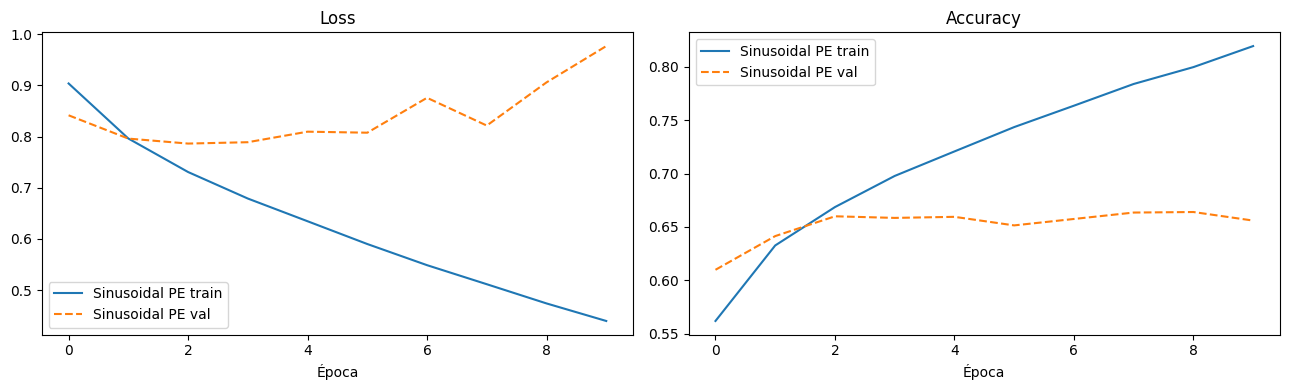


  Transformer + Sinusoidal PE — Test Accuracy: 0.5764
              precision    recall  f1-score   support

    negative     0.6168    0.4300    0.5067      3972
     neutral     0.5936    0.6731    0.6308      5937
    positive     0.4944    0.5794    0.5335      2375

    accuracy                         0.5764     12284
   macro avg     0.5683    0.5608    0.5570     12284
weighted avg     0.5819    0.5764    0.5719     12284



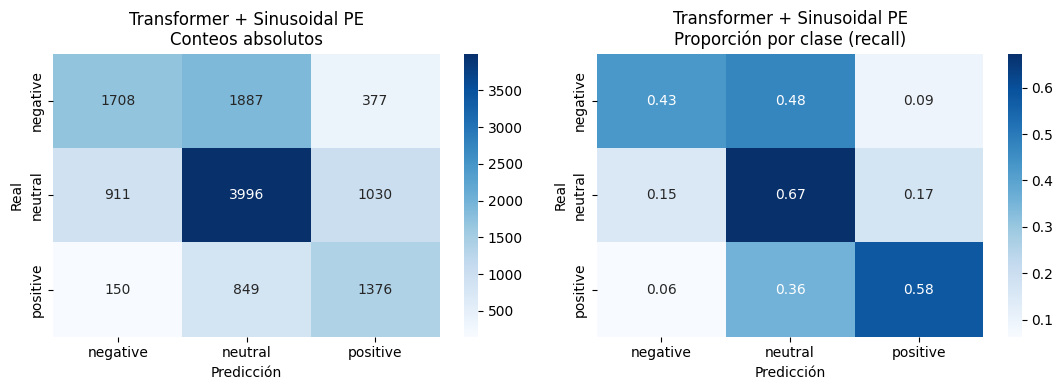

In [23]:
# =============================================================================
# 10. Evaluación comparativa en test
# =============================================================================
 
plot_history({
    "Sinusoidal PE": history3,
})

model3.load_state_dict(torch.load("transformer_sinusoidal_pe_best.pt",  map_location=DEVICE))
full_report(model3, test_loader, "Transformer + Sinusoidal PE")